In [1]:
import numpy as np

W = np.array([[1,2,3],[4,5,6]])
X = np.array([[0,1,2],[3,4,5]])
W + X

array([[ 1,  3,  5],
       [ 7,  9, 11]])

In [2]:
A = np.array([[1,2],[3,4]])
A * 10

array([[10, 20],
       [30, 40]])

In [3]:
A = np.array([[1,2],[3,4]])
b = np.array([10,20])
A * b

array([[10, 40],
       [30, 80]])

In [4]:
a = np.array([1,2,3])
b = np.array([4,5,6])
np.dot(a,b)

32

In [5]:
A = np.array([[1,2],[3,4]])
B = np.array([[5,6],[7,8]])
np.matmul(A,B)

array([[19, 22],
       [43, 50]])

In [6]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.random.randn(10,2)
W1 = np.random.randn(2,4)
b1 = np.random.randn(4)
W2 = np.random.randn(4,3)
b2 = np.random.randn(3)

h = np.matmul(x, W1) + b1
a = sigmoid(h)
s = np.matmul(a, W2) + b2

In [7]:
import numpy as np

class Sigmoid:
    def __init__(self):
        self.params = []

    def forward(self, x):
        return 1 / (1 + np.exp(-x))

class Affine:
    def __init__(self, W, b):
        self.params = [W, b]

    def forward(self, x):
        W, b = self.params
        out = np.matmul(x, W) + b
        return out

In [8]:
class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size):
        I, H, O = input_size, hidden_size, output_size

        W1 = 0.01 * np.random.randn(I, H)
        b1 = np.zeros(H)
        W2 = 0.01 * np.random.randn(H, O)
        b2 = np.zeros(O)

        self.layers = [Affine(W1, b1), Sigmoid(), Affine(W2, b2)]
        self.loss_layer = SoftmaxWithLoss()

        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def predict(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

In [9]:
import numpy as np
D, N = 8, 7
x = np.random.randn(1,D)
y = np.repeat(x, N, axis=0)
dy = np.random.randn(N, D)
dx = np.sum(dy, axis=0, keepdims=True)

In [10]:
class MatMul:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.x = None

    def forward(self, x):
        W, = self.params
        out = np.dot(x, W)
        self.x = x
        return out

    def backward(self, dout):
        W, = self.params
        dx = np.dot(dout, W.T)
        dW = np.dot(self.x.T, dout)
        self.grads[0][...] = dW
        return dx

In [11]:
class Sigmoid:
    def __init__(self):
        self.params, self.grads = [], []
        self.out = None

    def forward(self, x):
        out = 1 / (1 + np.exp(-x))
        self.out = out
        return out

    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out
        return dx

In [12]:
class Affine:
    def __init__(self, W, b):
        self.params = [W, b]
        self.grads = [np.zeros_like(W), np.zeros_like(b)]
        self.x = None

    def forward(self, x):
        W, b = self.params
        out = np.dot(x, W) + b
        self.x = x
        return out

    def backward(self, dout):
        W, b = self.params
        dx = np.dot(dout, W.T)
        dW = np.dot(self.x.T, dout)
        db = np.sumI(dout, axis=0)

        self.grads[0][...] = dW
        self.grads[1][...] = db
        return dx

In [13]:
class SoftmaxWithLoss:
    def __init__(self):
        self.params, self.grads = [], []
        self.y = None
        self.t = None

    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)

        if self.t.size == self.y.size:
            self.t = self.t.argmax(axis=1)

        loss = cross_entropy_error(self.y, self.t)
        return loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]

        dx = self.y.copy()
        dx[np.arange(batch_size), self.t] -= 1
        dx += dout
        dx = dx / batch_size

        return dx

In [14]:
class SGD:
    def __init__(self, lr = 0.01):
        self.lr = lr
    def update(self, params, grads):
        for i in range(len(params)):
            params[i] -= self.lr * grads[i]

x (300, 2)
t (300, 3)


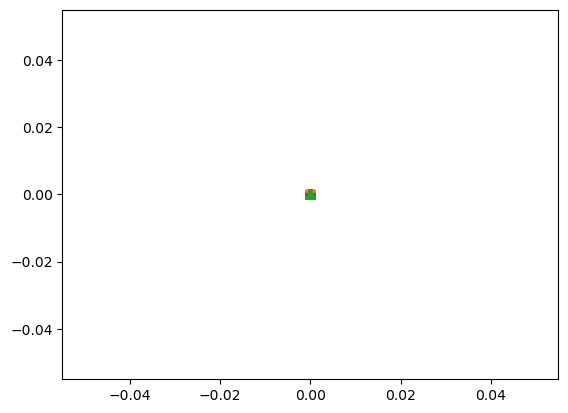

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('C:/Users/kohwo')
import spiral

import numpy as np

def load_data(seed=1984):
    N = 100  # 클래스당 샘플 수
    CLS_NUM = 3  # 클래스 수
    DIM = 2  # 데이터의 차원

    x = np.zeros((N*CLS_NUM, DIM))
    t = np.zeros((N*CLS_NUM, CLS_NUM), dtype=int)  # 수정된 부분

    for j in range(CLS_NUM):
        for i in range(N):  # N*j, N*(j+1)) :
            # 여기서 x와 t에 데이터 로딩
            pass

    return x, t

# 데이터 로딩
x, t = load_data()
print('x', x.shape)
print('t', t.shape)
n = 100
cls_num = 3
markers = ['o', 'x', '^']

for i in range(cls_num):
    plt.scatter(x[i * n : (i+1) * n, 0], x[i * n : (i+1) * n, 1], marker=markers[i])
plt.show()

In [16]:
class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size):
        I, H, O = input_size, hidden_size, output_size

        W1 = 0.01 * np.random.randn(I, H)
        b1 = np.zeros(H)
        W2 = 0.01 * np.random.randn(H, O)
        b2 = np.zeros(O)

        self.layers = [Affine(W1, b1), Sigmoid(), Affine(W2, b2)]
        self.loss_layer = SoftmaxWithLoss()

        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def predict(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def forward(self, x, t):
        score = self.predict(x)
        loss = self.loss_layer.forward(score, t)
        return loss

    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

| 에폭 1 | 반복 10 / 10 | 손실 0.14
| 에폭 2 | 반복 10 / 10 | 손실 0.01
| 에폭 3 | 반복 10 / 10 | 손실 0.01
| 에폭 4 | 반복 10 / 10 | 손실 0.00
| 에폭 5 | 반복 10 / 10 | 손실 0.00
| 에폭 6 | 반복 10 / 10 | 손실 0.00
| 에폭 7 | 반복 10 / 10 | 손실 0.00
| 에폭 8 | 반복 10 / 10 | 손실 0.00
| 에폭 9 | 반복 10 / 10 | 손실 0.00
| 에폭 10 | 반복 10 / 10 | 손실 0.00
| 에폭 11 | 반복 10 / 10 | 손실 0.00
| 에폭 12 | 반복 10 / 10 | 손실 0.00
| 에폭 13 | 반복 10 / 10 | 손실 0.00
| 에폭 14 | 반복 10 / 10 | 손실 0.00
| 에폭 15 | 반복 10 / 10 | 손실 0.00
| 에폭 16 | 반복 10 / 10 | 손실 0.00
| 에폭 17 | 반복 10 / 10 | 손실 0.00
| 에폭 18 | 반복 10 / 10 | 손실 0.00
| 에폭 19 | 반복 10 / 10 | 손실 0.00
| 에폭 20 | 반복 10 / 10 | 손실 0.00
| 에폭 21 | 반복 10 / 10 | 손실 0.00
| 에폭 22 | 반복 10 / 10 | 손실 0.00
| 에폭 23 | 반복 10 / 10 | 손실 0.00
| 에폭 24 | 반복 10 / 10 | 손실 0.00
| 에폭 25 | 반복 10 / 10 | 손실 0.00
| 에폭 26 | 반복 10 / 10 | 손실 0.00
| 에폭 27 | 반복 10 / 10 | 손실 0.00
| 에폭 28 | 반복 10 / 10 | 손실 0.00
| 에폭 29 | 반복 10 / 10 | 손실 0.00
| 에폭 30 | 반복 10 / 10 | 손실 0.00
| 에폭 31 | 반복 10 / 10 | 손실 0.00
| 에폭 32 | 반복 10 / 10 | 손실 0.00
| 에폭 33 | 반복 10 /

C:\Users\kohwo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kohwo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kohwo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kohwo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


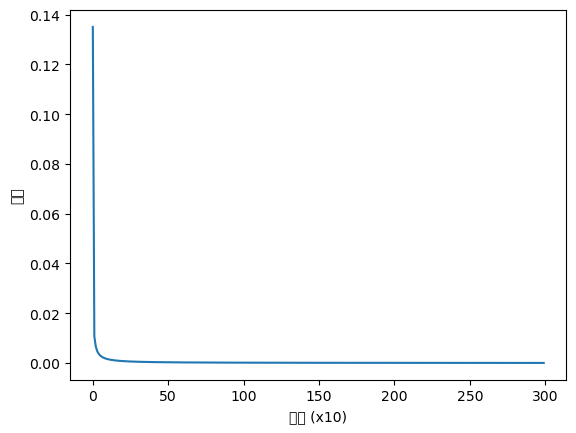

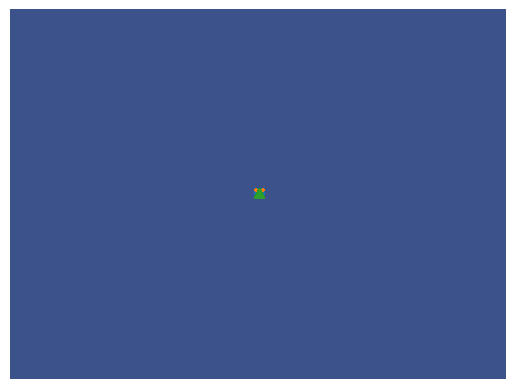

In [18]:
import sys
sys.path.append('C:/Users/kohwo/deep-learning-from-scratch-2-master')
import numpy as np
from common.optimizer import SGD
import spiral
import matplotlib.pyplot as plt
from two_layer_net import TwoLayerNet

max_epoch = 300
batch_size = 30
hidden_size = 10
learning_rate = 1.0

x, t = load_data()
model = TwoLayerNet(input_size=2, hidden_size=hidden_size, output_size=3)
optimizer = SGD(lr=learning_rate)

data_size = len(x)
max_iters = data_size // batch_size
total_loss = 0
loss_count = 0
loss_list = []

for epoch in range(max_epoch):
    idx = np.random.permutation(data_size)
    x = x[idx]
    t = t[idx]

    for iters in range(max_iters):
        batch_x = x[iters*batch_size:(iters+1)*batch_size]
        batch_t = t[iters*batch_size:(iters+1)*batch_size]

        loss = model.forward(batch_x, batch_t)
        model.backward()
        optimizer.update(model.params, model.grads)

        total_loss += loss
        loss_count += 1

        if (iters+1) % 10 == 0:
            avg_loss = total_loss / loss_count
            print('| 에폭 %d | 반복 %d / %d | 손실 %.2f' %(epoch+1, iters+1, max_iters, avg_loss))
            loss_list.append(avg_loss)
            total_loss, loss_count =0, 0

plt.plot(np.arange(len(loss_list)), loss_list, label='train')
plt.xlabel('반복 (x10)')
plt.ylabel('손실')
plt.show()

h = 0.001
x_min, x_max = x[:, 0].min() - .1, x[:, 0].max() + .1
y_min, y_max = x[:, 1].min() - .1, x[:, 1].max() + .1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
X = np.c_[xx.ravel(), yy.ravel()]
score = model.predict(X)
predict_cls = np.argmax(score, axis=1)
Z = predict_cls.reshape(xx.shape)
plt.contourf(xx, yy, Z)
plt.axis('off')

x, t = load_data()
n = 100
cls_num = 3
markers = ['o', 'x', '^']

for i in range(cls_num):
    plt.scatter(x[i * n : (i+1) * n, 0], x[i * n : (i+1) * n, 1], s=40, marker=markers[i])
plt.show()

| 에폭 1 |  반복 1 / 10 | 시간 0[s] | 손실 1.09
| 에폭 2 |  반복 1 / 10 | 시간 0[s] | 손실 0.03
| 에폭 3 |  반복 1 / 10 | 시간 0[s] | 손실 0.01
| 에폭 4 |  반복 1 / 10 | 시간 0[s] | 손실 0.01
| 에폭 5 |  반복 1 / 10 | 시간 0[s] | 손실 0.00
| 에폭 6 |  반복 1 / 10 | 시간 0[s] | 손실 0.00
| 에폭 7 |  반복 1 / 10 | 시간 0[s] | 손실 0.00
| 에폭 8 |  반복 1 / 10 | 시간 0[s] | 손실 0.00
| 에폭 9 |  반복 1 / 10 | 시간 0[s] | 손실 0.00
| 에폭 10 |  반복 1 / 10 | 시간 0[s] | 손실 0.00
| 에폭 11 |  반복 1 / 10 | 시간 0[s] | 손실 0.00
| 에폭 12 |  반복 1 / 10 | 시간 0[s] | 손실 0.00
| 에폭 13 |  반복 1 / 10 | 시간 0[s] | 손실 0.00
| 에폭 14 |  반복 1 / 10 | 시간 0[s] | 손실 0.00
| 에폭 15 |  반복 1 / 10 | 시간 0[s] | 손실 0.00
| 에폭 16 |  반복 1 / 10 | 시간 0[s] | 손실 0.00
| 에폭 17 |  반복 1 / 10 | 시간 0[s] | 손실 0.00
| 에폭 18 |  반복 1 / 10 | 시간 0[s] | 손실 0.00
| 에폭 19 |  반복 1 / 10 | 시간 0[s] | 손실 0.00
| 에폭 20 |  반복 1 / 10 | 시간 0[s] | 손실 0.00
| 에폭 21 |  반복 1 / 10 | 시간 0[s] | 손실 0.00
| 에폭 22 |  반복 1 / 10 | 시간 0[s] | 손실 0.00
| 에폭 23 |  반복 1 / 10 | 시간 0[s] | 손실 0.00
| 에폭 24 |  반복 1 / 10 | 시간 0[s] | 손실 0.00
| 에폭 25 |  반복 1 / 10 | 시간

C:\Users\kohwo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kohwo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kohwo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kohwo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


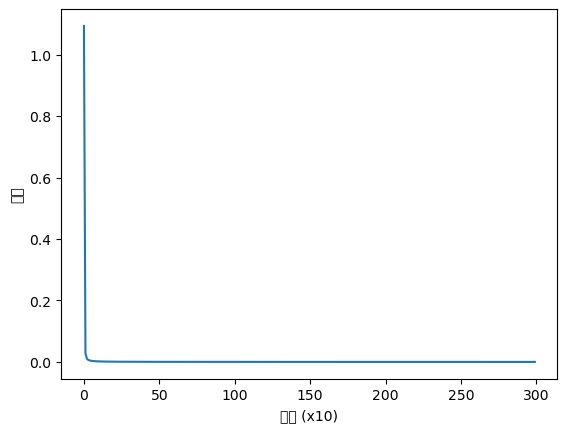

In [20]:
import sys
sys.path.append('C:/Users/kohwo')
import numpy as np
from common.optimizer import SGD
import spiral
import matplotlib.pyplot as plt
from two_layer_net import TwoLayerNet
from trainer import Trainer

max_epoch = 300
batch_size = 30
hidden_size = 10
learning_rate = 1.0

x, t = load_data()
model = TwoLayerNet(input_size=2, hidden_size=hidden_size, output_size=3)
optimizer = SGD(lr=learning_rate)

trainer = Trainer(model, optimizer)
trainer.fit(x, t, max_epoch, batch_size, eval_interval=10)
trainer.plot()